# Tutorial 4: Which Quantity? Extensive and Intensive Information

Tutorials 2 and 3 taught you to window a recording and hand the windows to an
estimator. Neither said what the resulting number *means*. That was deliberate,
and this tutorial is where the debt comes due.

Here is the problem in one sentence. For a time series there is no such thing
as "the" mutual information. There is a family of quantities, they answer
different questions, and the choice you make when you pick a window size
silently selects one of them.

This tutorial covers:

1. **The wall.** Windowed MI grows without bound as the window widens. There is
   no plateau on that axis, and we will show it exactly rather than by
   estimation.
2. **What an estimator does with an unbounded target.** The curve flattens, and
   the flattening is a property of the instrument rather than of the data.
3. **The chain rule.** The same information, asked for one time step at a time,
   keeps every question small enough to answer.
4. **History length as a model order.** The plateau you wanted does exist. It
   lives on a different axis.
5. **One primitive.** Every named quantity in the next two tutorials is
   `I(A; B | C)` with a different choice of time offsets.

By the end you will be able to say which quantity you are estimating, and why
that is the one your question needs.

## 0. Setup

Every notebook in this series carries one `SCALE` constant. It multiplies the
work: sample counts, training epochs, sweep repeats. The committed outputs were
produced at `SCALE = 1`, which keeps this notebook to a few minutes on a laptop.
Raise it when you want publication-grade numbers and have time to wait.

We also use an **oracle** here, and it is worth explaining why. Ordinary
generators give data whose MI you know for one specific pairing.
`SharedLatentGaussian` gives the exact value of `I(A; B | C)` for *any* choice
of variables and time offsets, computed in closed form rather than estimated.
That matters for this tutorial specifically: the claim is that windowed MI
diverges, and a claim about an estimand should be demonstrated on the estimand,
not on an estimate of it. Every curve in Sections 1 and 3 is exact linear
algebra with no neural network involved.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import neural_mi as nmi
from neural_mi.generators import SharedLatentGaussian

SCALE = 1          # raise for longer runs and tighter numbers
np.random.seed(0)

# Two observed processes driven by one shared AR(1) latent. phi sets the
# correlation timescale; d is the number of genuinely shared factors.
oracle = SharedLatentGaussian(dims={'x': 4, 'y': 4}, d=2, phi=0.9, seed=0)

print(f"correlation timescale tau : {oracle.tau:.2f} bins")
print(f"exact information rate    : {oracle.mi_rate():.4f} bits per bin")

correlation timescale tau : 9.49 bins
exact information rate    : 0.8368 bits per bin


## 1. The wall

The natural thing to do with a recording is chop it into windows of length `w`
and ask how much a window of X tells you about the matching window of Y. Call
that **block mutual information**, `I(X_1..w ; Y_1..w)`.

Tutorial 3 swept `window_size` and looked for the value where the curve settles.
Let us look at what the curve actually does. Because we have an oracle, we can
plot the true value at every window size with no estimation error at all.

In [2]:
widths = np.array([1, 2, 3, 5, 8, 12, 20, 30, 40, 60])
block_mi = np.array([oracle.block_mi(int(w)) for w in widths])

for w, v in zip(widths, block_mi):
    print(f"  w = {w:3d} bins   I(X_1..w ; Y_1..w) = {v:7.3f} bits")

  w =   1 bins   I(X_1..w ; Y_1..w) =   1.757 bits
  w =   2 bins   I(X_1..w ; Y_1..w) =   2.728 bits
  w =   3 bins   I(X_1..w ; Y_1..w) =   3.599 bits
  w =   5 bins   I(X_1..w ; Y_1..w) =   5.287 bits
  w =   8 bins   I(X_1..w ; Y_1..w) =   7.799 bits
  w =  12 bins   I(X_1..w ; Y_1..w) =  11.147 bits
  w =  20 bins   I(X_1..w ; Y_1..w) =  17.842 bits
  w =  30 bins   I(X_1..w ; Y_1..w) =  26.210 bits
  w =  40 bins   I(X_1..w ; Y_1..w) =  34.579 bits
  w =  60 bins   I(X_1..w ; Y_1..w) =  51.316 bits


It does not settle. It keeps climbing, and it climbs in a straight line.

Fitting a line to the large-`w` end recovers two numbers, and both of them mean
something.

In [3]:
slope, intercept = oracle.affine_fit(20, 60)
rate = oracle.mi_rate()

print(f"fit over w = 20..60:   I_w = {slope:.4f} * w + {intercept:.4f}")
print()
print(f"  slope     = {slope:.6f} bits per bin")
print(f"  rate      = {rate:.6f} bits per bin   (computed independently, "
      f"via the coherence integral)")
print(f"  agreement = {slope / rate:.6f}")
print()
print(f"  intercept = {intercept:.4f} bits")

fit over w = 20..60:   I_w = 0.8369 * w + 1.1045

  slope     = 0.836851 bits per bin
  rate      = 0.836819 bits per bin   (computed independently, via the coherence integral)
  agreement = 1.000038

  intercept = 1.1045 bits


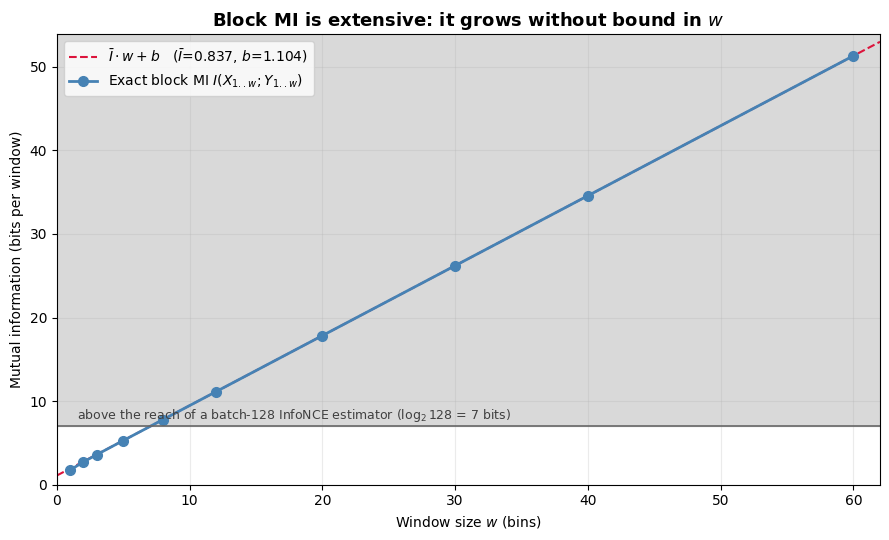

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))

w_dense = np.linspace(0, 62, 200)
ax.plot(w_dense, slope * w_dense + intercept, color='crimson', lw=1.5, ls='--',
        label=f'$\\bar{{I}} \\cdot w + b$   ($\\bar{{I}}$={slope:.3f}, $b$={intercept:.3f})')
ax.plot(widths, block_mi, 'o-', color='steelblue', lw=2, ms=7,
        label='Exact block MI $I(X_{1..w}; Y_{1..w})$')

# Where a default-batch InfoNCE estimator runs out of range.
ceiling = np.log2(128)
ax.axhspan(ceiling, block_mi.max() * 1.05, color='0.85', zorder=0)
ax.axhline(ceiling, color='0.4', lw=1.2)
ax.text(1.5, ceiling + 0.9, f'above the reach of a batch-128 InfoNCE estimator '
        f'($\\log_2 128$ = {ceiling:.0f} bits)', fontsize=9, color='0.25')

ax.set_xlabel('Window size $w$ (bins)')
ax.set_ylabel('Mutual information (bits per window)')
ax.set_title('Block MI is extensive: it grows without bound in $w$',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 62)
ax.set_ylim(0, block_mi.max() * 1.05)
ax.legend(loc='upper left')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Two things to take from that figure.

**There is no plateau, and there never will be.** The relationship is

$$I_w \;=\; \bar{I}\,w \;+\; b$$

and it holds to the precision of the arithmetic. Doubling the window roughly
doubles the answer. A quantity that grows in proportion to the size of the
system it is measured on is called **extensive**, which is the same sense in
which the mass of a rope is extensive and its density is not. Asking "what is
the MI of this recording" without fixing `w` is like asking how heavy rope is
without saying how much of it.

**The two fitted numbers are the quantities you actually wanted.**

- The **slope** is the *information rate* `Ī`, in bits per bin. It is intensive:
  a property of the coupling rather than of how much of it you looked at. Note
  that it was recovered here in two completely independent ways, by fitting the
  block curve and by a spectral integral, agreeing to six digits.
- The **intercept** is the *subextensive* part, worth roughly
  `b = 1.10` bits here. It does not grow with the window. This is the
  predictive information, and it is the piece that Tutorial 5 shows is a
  measure of structure rather than of duration.

So the window sweep was never useless. It was being read wrong. It measures a
line, and the line has two coefficients, and neither of them is "the value
where the curve flattens".

## 2. What an estimator does with an unbounded target

The curve above is the truth. An estimator has to find it from samples, and it
has a hard limit on how much it can report.

The default estimator, InfoNCE, scores each real pair against the other samples
in its batch. With `N` samples to contrast against, the most it can express is
`log2(N)` bits. At the default batch size of 128 that is 7 bits. The exact
curve passes 7 bits at a window of about 8 bins and reaches 26 bits by `w = 30`.

Let us watch what happens.

In [5]:
data = oracle.sample(T=int(8000 * SCALE), seed=0)

est_widths = [2, 5, 10, 20, 40]
estimates = []

for w in est_widths:
    r = nmi.run(
        data['x'], data['y'], mode='estimate',
        processing=nmi.Processing(x='continuous', y='continuous',
                                  x_params={'window_size': w},
                                  y_params={'window_size': w}),
        model=nmi.Model(embedding_dim=32, hidden_dim=128, n_layers=2),
        training=nmi.Training(n_epochs=int(40 * SCALE), patience=15, batch_size=128),
        n_workers=1, seed=0, show_progress=False,
    )
    estimates.append(r.mi_estimate)
    exact = oracle.block_mi(w)
    print(f"  w = {w:3d}   exact = {exact:7.3f}   estimated = {r.mi_estimate:6.3f} bits"
          f"   ({r.mi_estimate / exact:5.1%} of the true value)")

  w =   2   exact =   2.728   estimated =  2.790 bits   (102.3% of the true value)


neural_mi/analysis/task.py:367: UserWarning: Training completed all 40 epoch(s) without early stopping, and the best (smoothed) test MI occurred at the final epoch. MI may still have been increasing when training stopped, so the reported estimate could be an under-trained lower bound. Consider increasing n_epochs (or lowering patience to enable early stopping).
  results = trainer.train(


  w =   5   exact =   5.287   estimated =  4.713 bits   (89.2% of the true value)


  w =  10   exact =   9.473   estimated =  5.828 bits   (61.5% of the true value)


2026-08-26 00:41:32 - neural_mi - WARNING - InfoNCE estimate is near its ceiling: test MI (4.609 bits) vs. test ceiling log(test_eval_size=39)=5.285 bits. The true MI may be higher. Consider increasing max_eval_samples (and train_subset_size, if set) or switching to the 'smile' estimator for high-MI scenarios.


  w =  20   exact =  17.842   estimated =  6.027 bits   (33.8% of the true value)


  w =  40   exact =  34.579   estimated =  5.034 bits   (14.6% of the true value)


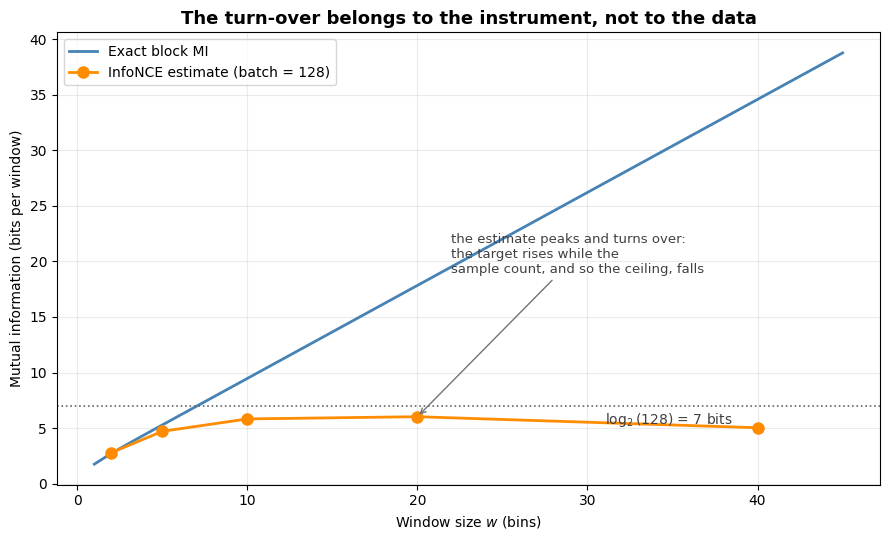

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))

w_fine = np.arange(1, 46)
ax.plot(w_fine, [oracle.block_mi(int(w)) for w in w_fine],
        color='steelblue', lw=2, label='Exact block MI')
ax.plot(est_widths, estimates, 'o-', color='darkorange', lw=2, ms=8,
        label='InfoNCE estimate (batch = 128)')

ceiling = np.log2(128)
ax.axhline(ceiling, color='0.4', lw=1.2, ls=':')
ax.text(31, ceiling - 1.6, f'$\\log_2(128)$ = {ceiling:.0f} bits', fontsize=10, color='0.25')

ax.annotate('the estimate peaks and turns over:\nthe target rises while the\nsample count, and so the ceiling, falls',
            xy=(20, estimates[3]), xytext=(22, 19),
            fontsize=9.5, color='0.25',
            arrowprops=dict(arrowstyle='->', color='0.45'))

ax.set_xlabel('Window size $w$ (bins)')
ax.set_ylabel('Mutual information (bits per window)')
ax.set_title('The turn-over belongs to the instrument, not to the data',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

The estimate tracks the truth while the truth is small, agreeing to within a
few percent at `w = 2` and `w = 5`. Then it comes apart. By `w = 20` it reports
a third of the true value, and by `w = 40` it reports a seventh.

**Look at the shape of the failure.** The estimate does not merely stop rising.
It peaks near 6 bits and then *turns over and falls*. That is worth dwelling on,
because a curve that rises, peaks and declines is exactly what you would expect
from a quantity that has a genuine optimum. Read without the exact curve behind
it, this figure says "the information peaks at a window of about 20 bins". The
truth is that the information is still climbing linearly and the instrument is
failing faster than the signal is growing.

**Why it falls rather than flattens.** Two effects compound as the window
widens. The target rises, linearly and forever. And the number of windows the
recording yields *falls*, because a longer window fits fewer times into a fixed
recording. Fewer windows means fewer contrastive samples, so the ceiling comes
down at the same time the target goes up.

The library noticed this during the run above. Among the output you will see:

> InfoNCE estimate is near its ceiling: test MI (4.609 bits) vs. test ceiling
> log(test_eval_size=39) = 5.285 bits.

Note which ceiling actually bound. Not `log2(128) = 7` from the batch size, but
`log2(39) = 5.285`, because at `w = 40` this recording only yields 39 test
windows. **The binding constraint is the sample count, not the knob.** Raising
`batch_size` here would do nothing at all: the library caps the batch at the
number of training samples, so above that the parameter is inert. The levers
that work are a longer recording, a shorter window, or a smaller step.

Your exact numbers will move from run to run. The shape will not.

## 3. The chain rule, and why the intensive route never hits a wall

The problem is not that the information is hard to measure. It is that we asked
for it all in one question.

The chain rule lets us take the same total apart, one time step at a time:

$$I(X; Y_1, \ldots, Y_w) \;=\; \sum_{t=1}^{w} I\!\left(X;\, Y_t \mid Y_1^{t-1}\right)$$

Each term asks a much smaller question: how much does X tell me about **one**
time bin of Y, given the bins of Y that came before it? Let us look at those
terms.

In [7]:
K = 12
x_two_sided = [('x', s) for s in range(-K, K + 1)]

print("  t    I(X ; Y_t | Y_1..t-1)")
print("  " + "-" * 34)
increments = []
for t in range(9):
    val = oracle.exact(x_two_sided, [('y', 0)], [('y', s) for s in range(-t, 0)])
    increments.append(val)
    note = "  <- no Y history yet" if t == 0 else ""
    print(f"  {t}         {val:.6f}{note}")

print(f"\n  exact rate:  {oracle.mi_rate():.6f} bits per bin")

  t    I(X ; Y_t | Y_1..t-1)
  ----------------------------------
  0         2.309751  <- no Y history yet
  1         0.908535
  2         0.847650
  3         0.838785
  4         0.837205
  5         0.836915
  6         0.836862
  7         0.836853
  8         0.836851

  exact rate:  0.836819 bits per bin


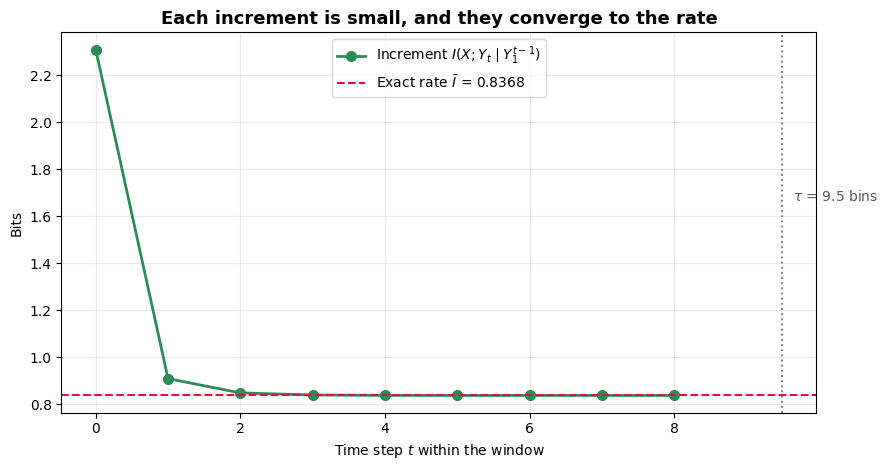

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.8))

ax.plot(range(len(increments)), increments, 'o-', color='seagreen', lw=2, ms=7,
        label='Increment $I(X; Y_t \\mid Y_1^{t-1})$')
ax.axhline(oracle.mi_rate(), color='crimson', ls='--', lw=1.5,
           label=f'Exact rate $\\bar{{I}}$ = {oracle.mi_rate():.4f}')
ax.axvline(oracle.tau, color='0.5', ls=':', lw=1.4)
ax.text(oracle.tau + 0.15, max(increments) * 0.72,
        f'$\\tau$ = {oracle.tau:.1f} bins', fontsize=10, color='0.35')

ax.set_xlabel('Time step $t$ within the window')
ax.set_ylabel('Bits')
ax.set_title('Each increment is small, and they converge to the rate',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

The first term is large because it has no history to condition on, so it carries
the subextensive part as well. From the second term onward the increments fall
quickly and settle onto the rate, matching it to six decimal places by `t = 6`.

Two consequences, and they are the heart of this tutorial.

**Every question is small.** The largest increment after the first is under 1
bit, against a ceiling of 7. The sum of thirty of them is 26 bits, which is far
past the ceiling, but nothing ever asks for 26 bits at once. Estimating the rate
directly means asking a question the instrument can comfortably answer, however
long the recording is. The extensive route routes an intensive quantity through
a number that outgrows the instrument, for no reason other than how the question
was posed.

**The convergence point is a measurement.** The increments settle after about
six or seven steps, and the correlation timescale of this system is
`tau = 9.5` bins. So the number of steps you need to condition on before the
increments stop changing *is* the dependence timescale, measured with mutual
information itself. You get it for free, without a separate autocorrelation
analysis, and unlike autocorrelation it responds to nonlinear dependence too.

## 4. The plateau you wanted, on the axis where it exists

Section 1 killed the plateau on the window axis. It does exist, on a different
one.

To estimate the rate you have to choose how much history to condition on. Call
it `k`. That choice is not an estimand, it is a **model order**: how much of the
past you assume matters. Sweep it and watch.

In [9]:
k_values = [1, 2, 3, 5, 8, 12, 20, 30]
rate_vs_k = [oracle.exact([('x', s) for s in range(-k, k + 1)],
                          [('y', 0)],
                          [('y', s) for s in range(-k, 0)]) for k in k_values]

for k, v in zip(k_values, rate_vs_k):
    print(f"  k = {k:3d}   rate estimate = {v:.6f} bits per bin")

  k =   1   rate estimate = 0.850947 bits per bin
  k =   2   rate estimate = 0.833273 bits per bin
  k =   3   rate estimate = 0.834165 bits per bin
  k =   5   rate estimate = 0.836337 bits per bin
  k =   8   rate estimate = 0.836824 bits per bin
  k =  12   rate estimate = 0.836851 bits per bin
  k =  20   rate estimate = 0.836851 bits per bin
  k =  30   rate estimate = 0.836851 bits per bin


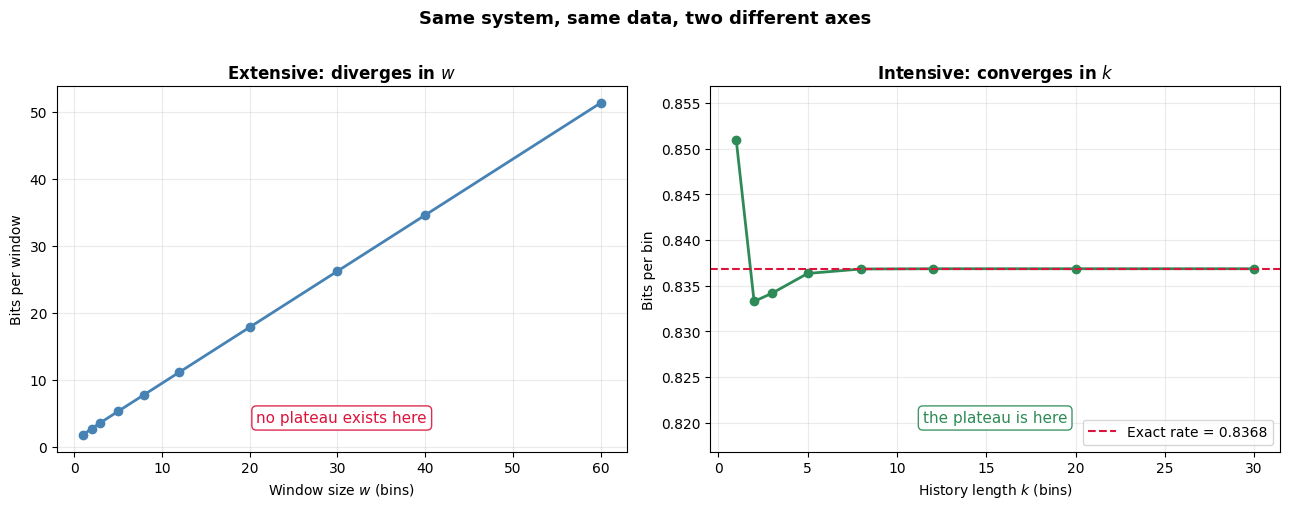

In [10]:
fig, (ax_w, ax_k) = plt.subplots(1, 2, figsize=(13, 5))

ax_w.plot(widths, block_mi, 'o-', color='steelblue', lw=2, ms=6)
ax_w.set_xlabel('Window size $w$ (bins)')
ax_w.set_ylabel('Bits per window')
ax_w.set_title('Extensive: diverges in $w$', fontsize=12, fontweight='bold')
ax_w.grid(alpha=0.25)
ax_w.text(0.5, 0.08, 'no plateau exists here', transform=ax_w.transAxes,
          ha='center', fontsize=11, color='crimson',
          bbox=dict(boxstyle='round', fc='white', ec='crimson', alpha=0.9))

ax_k.plot(k_values, rate_vs_k, 'o-', color='seagreen', lw=2, ms=6)
ax_k.axhline(oracle.mi_rate(), color='crimson', ls='--', lw=1.5,
             label=f'Exact rate = {oracle.mi_rate():.4f}')
ax_k.set_xlabel('History length $k$ (bins)')
ax_k.set_ylabel('Bits per bin')
ax_k.set_title('Intensive: converges in $k$', fontsize=12, fontweight='bold')
ax_k.set_ylim(oracle.mi_rate() - 0.02, oracle.mi_rate() + 0.02)
ax_k.legend(loc='lower right')
ax_k.grid(alpha=0.25)
ax_k.text(0.5, 0.08, 'the plateau is here', transform=ax_k.transAxes,
          ha='center', fontsize=11, color='seagreen',
          bbox=dict(boxstyle='round', fc='white', ec='seagreen', alpha=0.9))

fig.suptitle('Same system, same data, two different axes',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Same system on both panels. On the left the quantity diverges and the sweep has
no stopping rule. On the right it converges by `k = 8` and stays converged,
which gives you a principled place to stop: increase `k` until the answer stops
moving, then stop.

Note the vertical scale on the right panel. It spans four hundredths of a bit.
The convergence is not approximate.

**Why the trade is worth taking.** Longer history means a higher-dimensional
input to the critic, and the bias grows with input dimension. So the intensive
route replaces a hard ceiling with a soft capacity limit. That is a good trade,
because a capacity limit shows up as underfitting, which is detectable, whereas
a ceiling collision shows up as a plateau, which looks like a result.

## 5. One primitive, many quantities

Everything above used the same function with different arguments, and that is
the organising idea for the rest of the series.

$$I(A;\, B \mid C)$$

where `A`, `B` and `C` are sets of `(process, time offset)` pairs. Each named
quantity in the literature is one choice of those three sets:

| Quantity | A | B | C |
|---|---|---|---|
| Instantaneous MI | `X_0` | `Y_0` | (none) |
| Block MI | `X_1..w` | `Y_1..w` | (none) |
| MI rate | `X_-k..+k` | `Y_0` | `Y_-k..-1` |
| Active information storage | `X_-k..-1` | `X_0` | (none) |
| Excess entropy | `X_-k..-1` | `X_0..k-1` | (none) |
| Transfer entropy, X to Y | `X_-k..-1` | `Y_0` | `Y_-k..-1` |
| Instantaneous exchange | `X_0` | `Y_0` | `X_-k..-1`, `Y_-k..-1` |
| Directed information rate | `X_-k..0` | `Y_0` | `Y_-k..-1` |

They are not different mathematical objects requiring different estimators. They
are different questions posed to one estimator. Tutorial 5 works through the
storage and rate rows, Tutorial 6 through the directed ones.

The library exposes this directly, so a quantity with no named wrapper is still
one call away.

In [11]:
from neural_mi.utils import build_offset_arrays

# Transfer entropy from X to Y, written as its offset pattern.
spec = {'A': [('x', s) for s in range(-8, 0)],   # X's past
        'B': [('y', 0)],                          # Y's present
        'C': [('y', s) for s in range(-8, 0)]}    # given Y's own past

a, b, c, n_valid = build_offset_arrays({'x': data['x'], 'y': data['y']}, spec)
print(f"A {tuple(a.shape)}   B {tuple(b.shape)}   C {tuple(c.shape)}   "
      f"n_valid = {n_valid}")
print(f"\nexact value for this pattern: "
      f"{oracle.exact(spec['A'], spec['B'], spec['C']):.4f} bits")

A (7992, 4, 8)   B (7992, 4, 1)   C (7992, 4, 8)   n_valid = 7992

exact value for this pattern: 0.0460 bits


The dispatch rule from an offset pattern to a call is two cases:

- **`C` is empty**: `run(A, B, mode='estimate')`.
- **`C` is populated**: `run(A, B, mode='conditional', conditional=Conditional(
  w_data=C, align='dual_branch'))`. The dual branch is needed because `A`, `B`
  and `C` usually have different window lengths, `B` typically being a single
  bin while `A` and `C` span many.

That is the entire mechanism. No quantity in the next two tutorials adds
estimation machinery beyond this.

## 6. A caveat specific to spike data

One thing that does not show up on continuous data, and bites hard on spikes.

A spike window containing no spikes is discarded by default. That is sensible
for windowed MI, since an empty window has no pattern to learn. It also means
the retained fraction of your recording changes as the window widens, because a
wider window is likelier to catch a spike. Measured on a 3 Hz population, the
retained fraction climbs from 0.155 at 20 ms windows to 1.0 at 1 s windows.

So on spike data a window sweep has a **second** thing moving with `w`, on top
of the extensivity: the subensemble being measured is expanding. Both push the
estimate up, and the fitted slope conflates them.

The fix is to keep silent windows, which pins the retained fraction at 1.0
across the sweep:

```python
processing=nmi.Processing(x='spike', x_params={'window_size': w,
                                               'drop_empty_windows': False})
```

This is only safe when the recording is genuinely observed throughout, because
no-spikes and not-recorded look identical in a spike-time list. Tutorial 6
returns to this with real data. The retained fraction is reported as
`window_retention` in the results, so you can always check which regime you are
in.

## 7. Key Takeaways

- **Windowed MI is extensive.** `I_w = Ī·w + b`, growing without bound. Sweeping
  `window_size` and looking for a plateau is looking for something that does not
  exist on that axis.

- **The sweep is still worth running, read as a line.** The slope is the
  information rate, intensive and comparable across recordings. The intercept is
  the subextensive predictive information.

- **A curve that peaks and turns over can be pure instrument.** InfoNCE cannot
  report more than `log2(N)` bits for `N` contrastive samples, and a wider window
  yields fewer samples. Target up, ceiling down, and the result looks like a
  genuine optimum.

- **The chain rule keeps every question small.** Asking one time step at a time
  never approaches the ceiling, however long the recording is.

- **The plateau exists on the history axis.** `k` is a model order rather than
  an estimand: raise it until the answer stops moving. The step count at which
  the increments settle is itself a measurement of the dependence timescale.

- **Every named quantity is `I(A;B|C)` under a different offset pattern.** One
  primitive, many questions.

- **On spike data, check `window_retention`.** The subensemble can move under
  you as the window changes.

## Common Mistakes

1. **Reporting a windowed MI without its window size.** The number is
   meaningless on its own, in the same way that "this rope weighs 4 kg" says
   nothing about the rope until you say how long it is. Report the rate, or
   report the window alongside the value.

2. **Reading a flattening curve as convergence.** Check the estimate against
   `log2(batch_size)` and against `log2(n_test)`. If it is close to either, you
   are probably looking at the instrument rather than the data.

3. **Raising `batch_size` to lift the ceiling without checking sample count.**
   The library caps the batch at the number of training samples, so above that
   the parameter does nothing at all. The real lever is having more samples: a
   longer recording, a shorter window, or a smaller step.

4. **Sweeping `window_size` on spike data without pinning
   `drop_empty_windows`.** The retained fraction moves with the window and
   inflates the slope.

5. **Choosing `k` by eye instead of by convergence.** Sweep it and stop where
   the answer stops moving. That is a stopping rule; a guess is not.

## What's Next

**Tutorial 5** works through the single-process and symmetric quantities:
active information storage, excess entropy, instantaneous MI, block MI, the MI
rate and cross-predictive information. Each is an offset pattern, and each is
checked against its exact value so you can see how far an estimate sits from the
truth on a problem where the truth is known.

**Tutorial 6** turns to direction. Mutual information is symmetric, so it cannot
tell you which process drives which. Conditioning on a process's own past breaks
that symmetry, which gives transfer entropy, instantaneous exchange and the
directed information rate, tied together by an exact conservation law.